<a href="https://colab.research.google.com/github/mathiasnikitha07-cell/Nikitha/blob/main/Linear_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data=pd.read_csv("/content/Student_Performance1.csv")
data.head(5)
##data.tail(4)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,0,9,1,91
1,4,82,0,4,2,65
2,8,51,0,7,2,45
3,5,52,1,5,2,36
4,7,75,1,8,5,66


In [ ]:
data.shape

(10000, 6)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [ ]:
data.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
data.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.442600,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.496719,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [ ]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

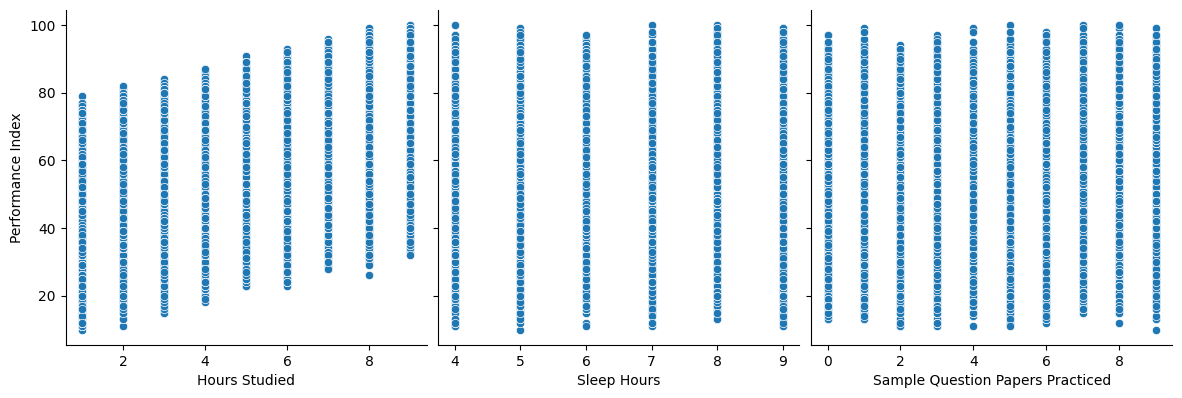

In [ ]:
sn.pairplot(data,x_vars=['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced'],y_vars=['Performance Index'],height=4,aspect=1,kind="scatter")

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


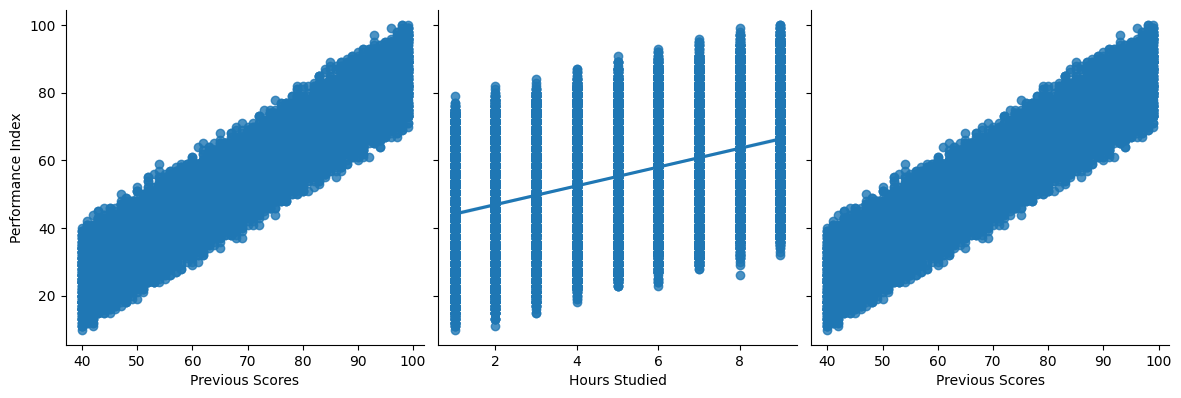

In [ ]:
sn.pairplot(data,x_vars=['Previous Scores', 'Hours Studied', 'Previous Scores'],y_vars=['Performance Index'],size=4,aspect=1,kind="reg")

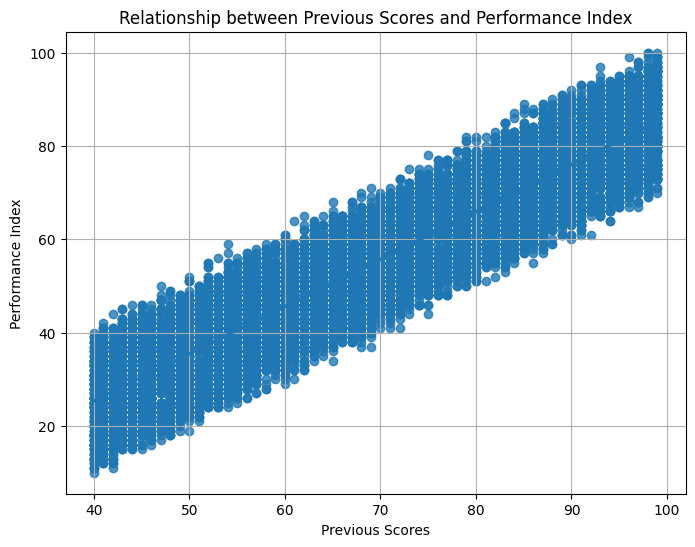

In [ ]:
plt.figure(figsize=(8, 6))
sn.regplot(x='Previous Scores', y='Performance Index', data=data)
plt.title('Relationship between Previous Scores and Performance Index')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.grid(True)
plt.show()

In [ ]:
data.select_dtypes(include=np.number).corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,-0.003233,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,-0.002713,0.005944,0.007888,0.915189
Extracurricular Activities,-0.003233,-0.002713,1.000000,-0.006225,0.031340,-0.002337
Sleep Hours,0.001245,0.005944,-0.006225,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.031340,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,-0.002337,0.048106,0.043268,1.000000


<Axes: >

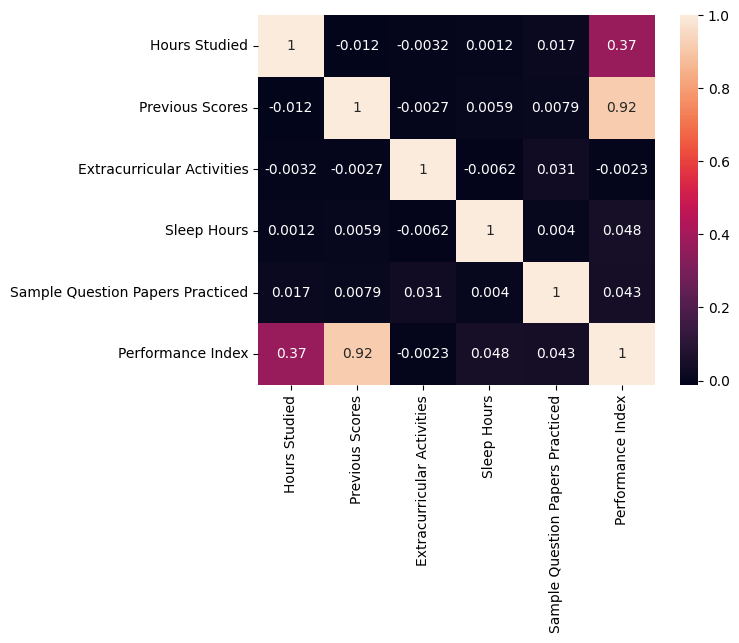

In [ ]:
sn.heatmap(data.select_dtypes(include=np.number).corr(), annot=True)

In [ ]:
X=data[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']]
y=data['Performance Index']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
model.score(X_train ,Y_train)

0.988480973655825

In [ ]:
model.score(X_test,Y_test)

0.9885595115192362

In [ ]:
model.intercept_

np.float64(-33.73412427250872)

In [ ]:
model.coef_

array([2.85393018, 1.01822967, 0.47440162, 0.19436098])

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([46.49298252, 31.19870409, 30.1676787 , ..., 76.15860129,
       74.73616844, 68.35877345])

In [ ]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(Y_test,y_pred)
mae

1.6402020406031461

In [ ]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(Y_test,y_pred)
mse

4.266328935228771

In [ ]:
from math import sqrt
rms = sqrt(mean_squared_error(Y_test,y_pred))
rms

2.0655093645947895

In [ ]:
print(mae,mse,rms)

1.6402020406031461 4.266328935228771 2.0655093645947895


In [ ]:
import statsmodels.api as sm

In [ ]:
X = sm.add_constant(X)

In [ ]:
results = sm.OLS(y,X).fit()

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 2.147e+05
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        11:44:29   Log-Likelihood:                -21418.
No. Observations:               10000   AIC:                         4.285e+04
Df Residuals:                    9995   BIC:                         4.288e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=100)

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
e_net = ElasticNet()
e_net.fit(X_train, y_train)

ElasticNet()

In [ ]:
e_net.score(X_test, y_test)

0.9857792393112552

In [ ]:
y_pred = e_net.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mse

5.496721831980145

In [ ]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
mae

1.8459040643431497

In [ ]:
from sklearn.metrics import log_loss

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Student_Performance1.csv')
df.head(2)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,0,9,1,91
1,4,82,0,4,2,65


In [ ]:
df.shape

(10000, 6)

In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Extracurricular Activities']=le.fit_transform(df['Extracurricular Activities'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [ ]:
df['Previous Scores'] = df['Previous Scores'].fillna(df['Previous Scores'].mean())

In [ ]:
df["Sleep Hours"].fillna(df["Sleep Hours"].mean(),inplace=True)

/tmp/ipykernel_3935/3438520525.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sleep Hours"].fillna(df["Sleep Hours"].mean(),inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [ ]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
model.score(X_test,y_test)

0.1375

In [ ]:
y_predict=model.predict(X_test)

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge()

In [ ]:
ridge.fit(X_train,y_train)

Ridge()

In [ ]:
ridge.score(X_test,y_test)

0.9890367661457966

In [ ]:
y_predict=ridge.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_predict)
mae

1.597463164690946

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso()

In [ ]:
lasso.fit(X_train,y_train)

Lasso()

In [ ]:
lasso.score(X_test,y_test)

0.9872430309875523

In [ ]:
predict=lasso.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,predict)
mae

1.7278120887512536

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]}
ridge_regressor = GridSearchCV(ridge, parameters,scoring='neg_mean_squared_error')  ## CV=5
ridge_regressor.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.16686e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.16787e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.19169e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.17005e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.14257e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20]},
             scoring='neg_mean_squared_error')

In [ ]:
ridge_regressor.score(X_test,y_test)

-4.121633530835465

In [ ]:
ridge_regressor.best_estimator_

Ridge(alpha=1e-15)

In [ ]:
ridge_regressor.best_params_

{'alpha': 1e-15}

In [ ]:
ridge_regressor.best_score_

np.float64(-4.283045991711367)

In [ ]:
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv = 5)
lasso_regressor.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.733e+03, tolerance: 2.358e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.336e+04, tolerance: 2.369e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.287e+04, tolerance: 2.319e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20]},
             scoring='neg_mean_squared_error')

In [ ]:
lasso_regressor.score(X_test,y_test)

-4.121633530835461

In [ ]:
lasso_regressor.best_params_

{'alpha': 1e-15}

In [ ]:
lasso_regressor.best_score_

np.float64(-4.283045991711368)

In [ ]:
lasso1=lasso.predict(X_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]}

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(max_iter=1000)

In [ ]:
lasso=RandomizedSearchCV(lasso,parameters,cv=4)
lasso.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.518e+04, tolerance: 2.768e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.574e+04, tolerance: 2.783e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.552e+04, tolerance: 2.753e

RandomizedSearchCV(cv=4, estimator=Lasso(),
                   param_distributions={'alpha': [1e-15, 1e-10, 1e-08, 0.0001,
                                                  0.001, 0.01, 1, 5, 10, 20]})

In [ ]:
lasso.best_estimator_

Lasso(alpha=1e-15)

In [ ]:
lasso.best_index_

np.int64(0)

In [ ]:
lasso.best_params_

{'alpha': 1e-15}

In [ ]:
lasso.best_score_

np.float64(0.9884868297132802)

In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
ridge=RandomizedSearchCV(ridge,parameters,cv=10)
ridge.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.58592e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.60106e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.57947e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.60843e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.61011e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

RandomizedSearchCV(cv=10, estimator=Ridge(),
                   param_distributions={'alpha': [1e-15, 1e-10, 1e-08, 0.0001,
                                                  0.001, 0.01, 1, 5, 10, 20]})

In [ ]:
ridge.best_estimator_

Ridge(alpha=5)

In [ ]:
ridge.best_index_

np.int64(7)

In [ ]:
ridge.best_params_

{'alpha': 5}

In [ ]:
ridge.best_score_

np.float64(0.9883110088543996)

In [ ]:
print(ridge.score(X_test,y_test))

0.9890363715571228
